# Ljubljana Transit Simulation Analysis

This notebook analyzes the results of the random walk meeting simulations conducted on the LPP transit graph.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Load data
df = pd.read_csv('simulation_results.csv')

# Separate meetings from timeouts
meetings = df[df['meeting_name'] != 'TIMEOUT'].copy()
timeouts = df[df['meeting_name'] == 'TIMEOUT'].copy()

print(f"Total Simulations: {len(df)}")
print(f"Successful Meetings: {len(meetings)}")
print(f"Meeting Rate: {len(meetings)/len(df)*100:.1f}%")
if len(meetings) > 0:
    print(f"Average Meeting Time: {meetings['meeting_step'].mean():.2f} steps")

Total Simulations: 1000
Successful Meetings: 519
Meeting Rate: 51.9%
Average Meeting Time: 2069.72 steps


C:\Users\Lara\AppData\Local\Temp\ipykernel_1760\3381616058.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_hubs.values, y=top_hubs.index, palette="viridis")


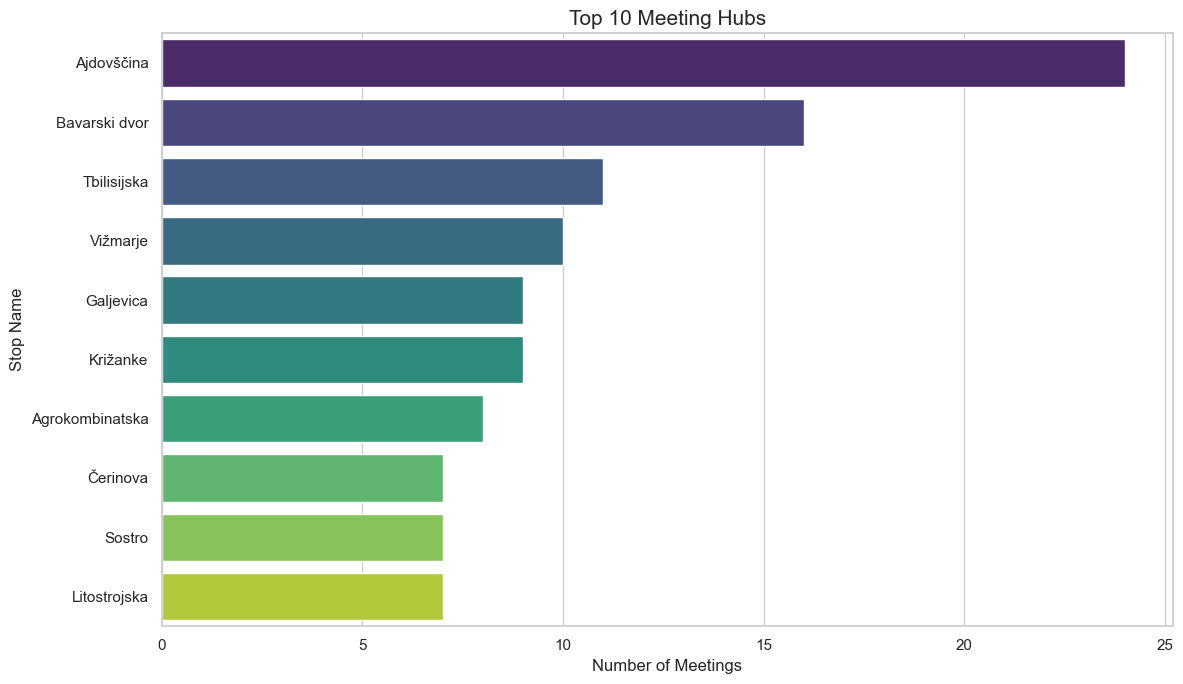

In [2]:
if len(meetings) > 0:
    # Top Meeting Hubs
    top_hubs = meetings['meeting_name'].value_counts().head(10)

    plt.figure(figsize=(12, 7))
    sns.barplot(x=top_hubs.values, y=top_hubs.index, palette="viridis")
    plt.title('Top 10 Meeting Hubs', fontsize=15)
    plt.xlabel('Number of Meetings', fontsize=12)
    plt.ylabel('Stop Name', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No successful meetings to visualize hubs.")

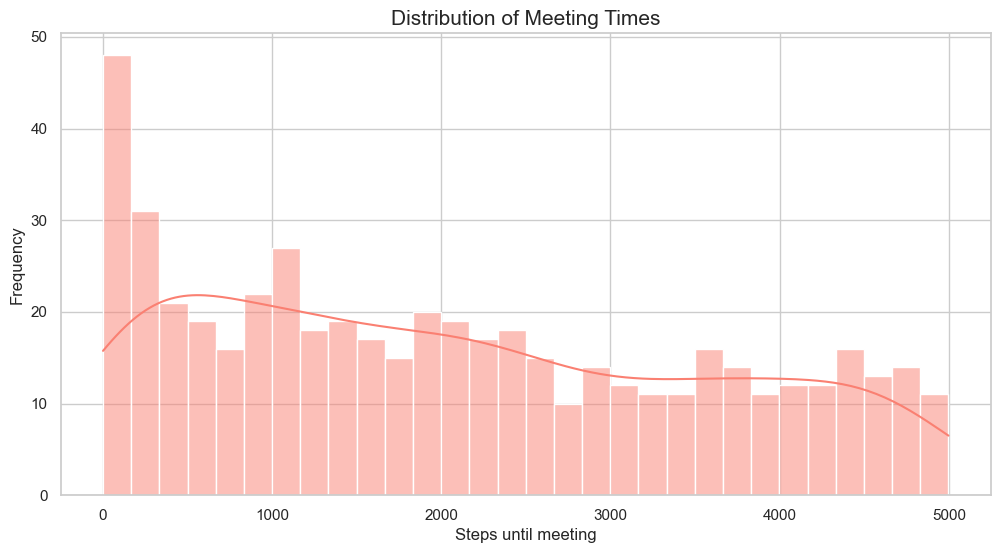

In [3]:
if len(meetings) > 0:
    # Distribution of Meeting Times
    plt.figure(figsize=(12, 6))
    sns.histplot(meetings['meeting_step'], bins=30, kde=True, color='salmon')
    plt.title('Distribution of Meeting Times', fontsize=15)
    plt.xlabel('Steps until meeting', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.show()
else:
    print("No successful meetings to visualize distribution.")